# Bitcoin

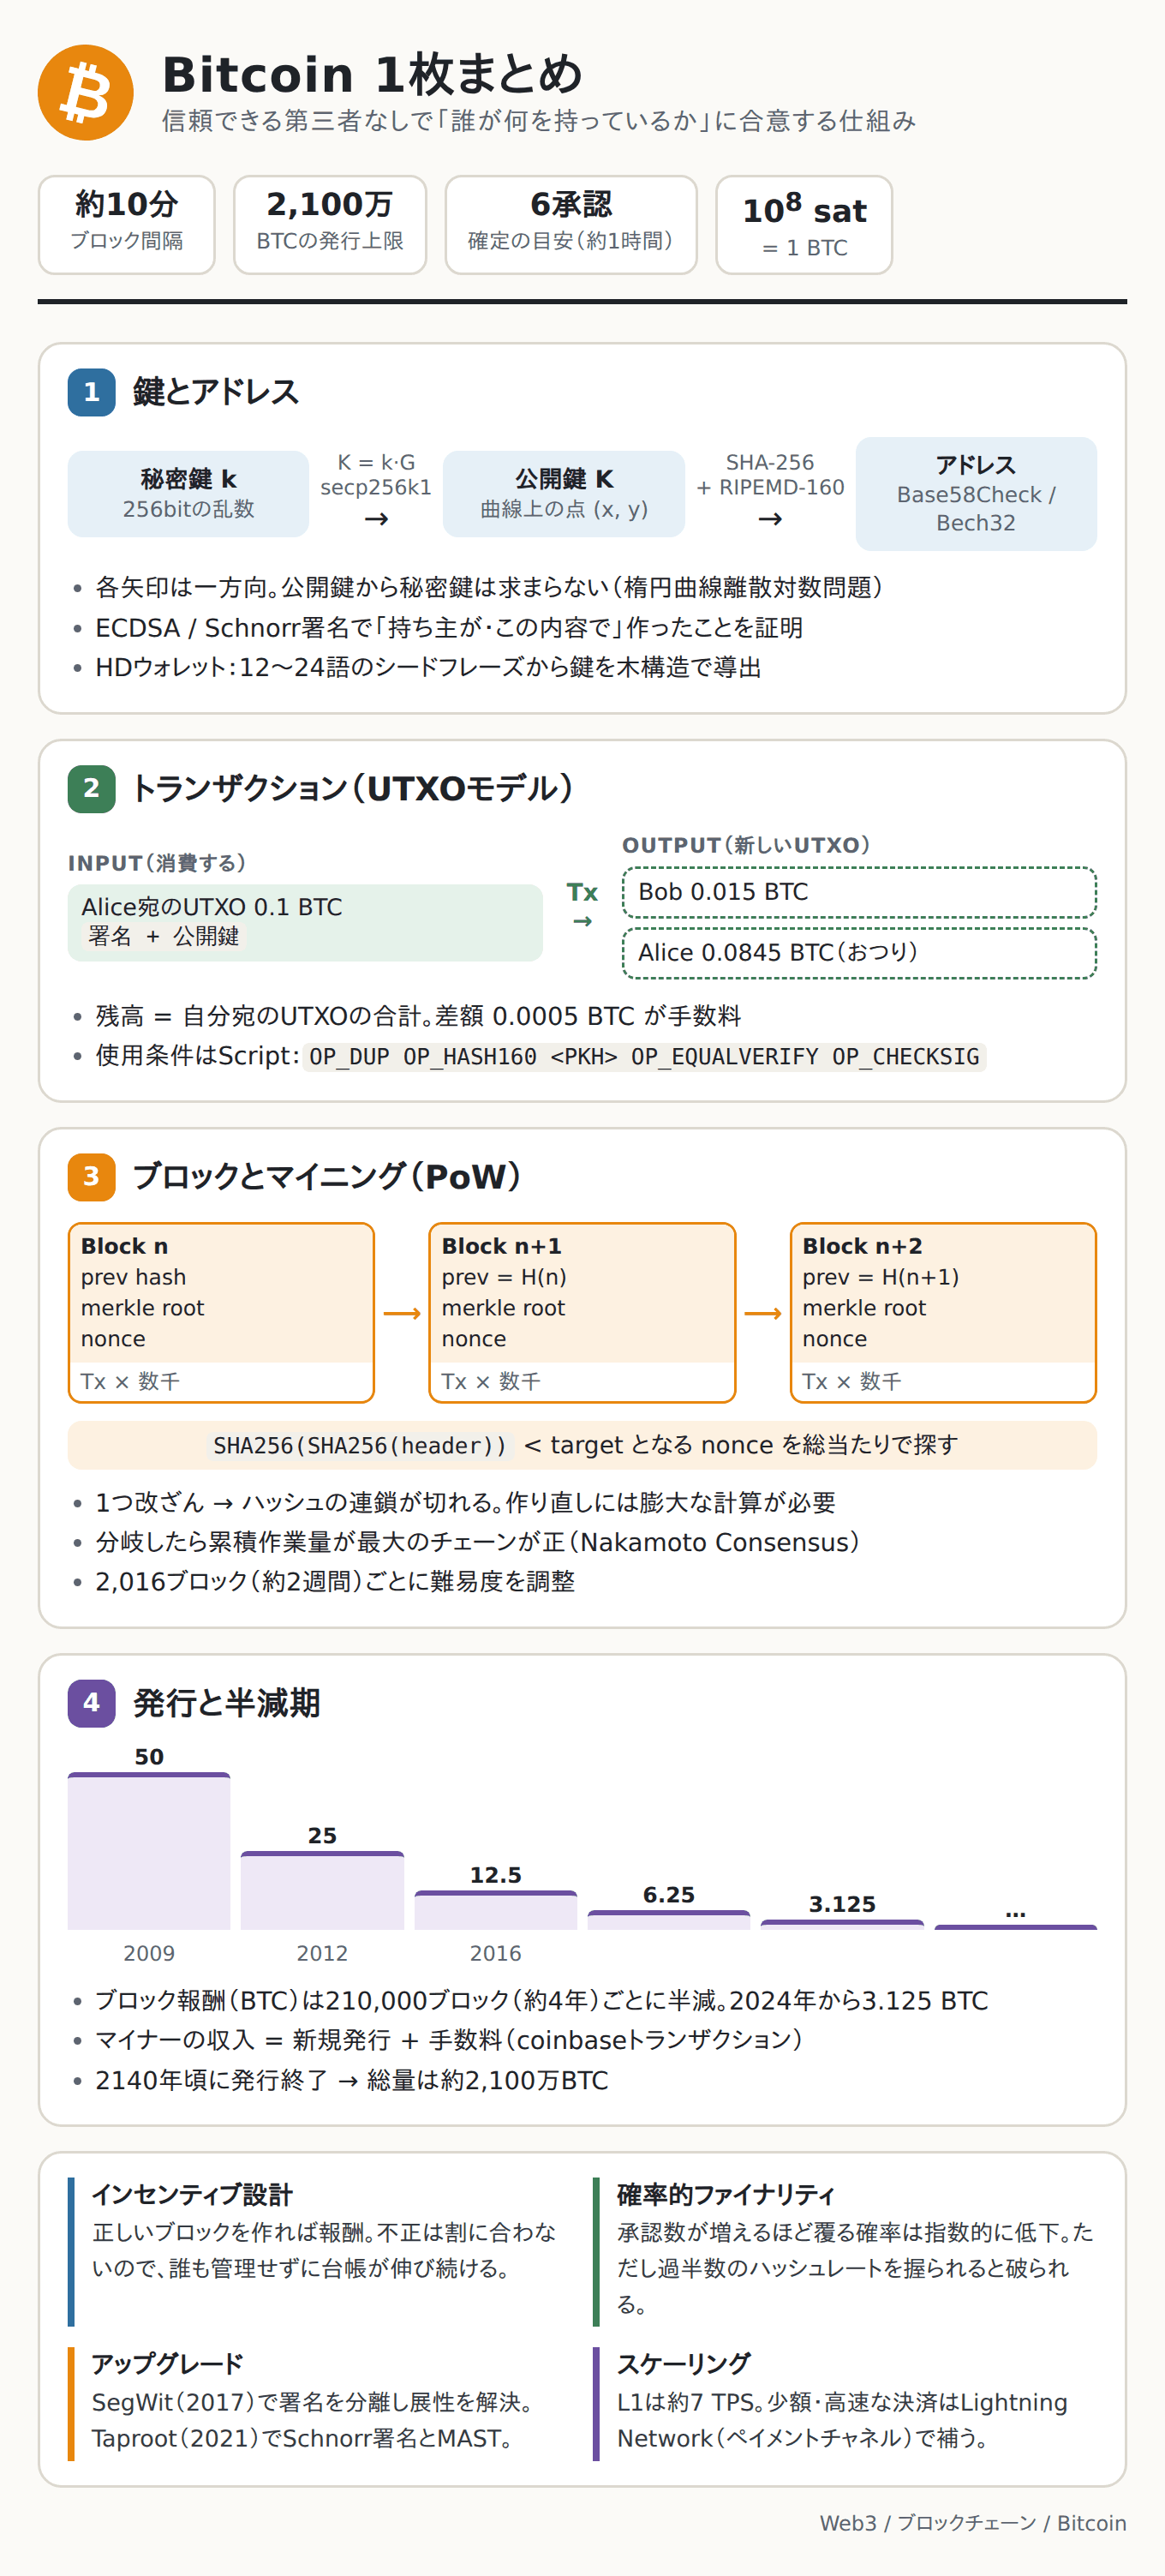

**Bitcoin** は2008年にSatoshi Nakamotoが論文で提案し、2009年1月に稼働を始めた最初のブロックチェーン。システムとしてのBitcoin（プロトコル）と、その上で発行される通貨単位のbitcoin（BTC）を区別して書くことがある。

最小単位は **satoshi**（1 BTC = $10^8$ satoshi）。

ここではBitcoinの構成要素を、鍵とアドレス → トランザクション → マイニングと発行の順に見ていく。

## 鍵とアドレス

### 公開鍵暗号とデジタル署名

トランザクションには「アドレスの持ち主が」「この内容で」作ったことの証明が必要。それがないと、中継するノードやマイナーが内容を書き換えられてしまう。そこで **デジタル署名（digital signature）** を付ける。

1. 送金者は **秘密鍵（private key）** と **公開鍵（public key）** のペアを作る
2. 秘密鍵でトランザクションの要約に署名する
3. トランザクションに署名と公開鍵を載せる
4. 誰でも公開鍵を使って署名を検証できる

検証者は秘密鍵を知らなくても「この署名を作れるのは公開鍵に対応する秘密鍵の持ち主だけ」「署名された内容と受け取った内容が一致する」ことを確認できる。

BitcoinはECDSA（楕円曲線デジタル署名アルゴリズム）を採用している（2021年のTaprootアップグレード以降はSchnorr署名も使える）。

### 秘密鍵・公開鍵・アドレスの関係

```mermaid
flowchart LR
    k["秘密鍵 k<br/>256bitの乱数"] -->|"楕円曲線の乗算<br/>K = k·G"| K["公開鍵 K<br/>曲線上の点 (x, y)"]
    K -->|"SHA-256 + RIPEMD-160"| PKH["公開鍵ハッシュ<br/>160bit"]
    PKH -->|"Base58Check"| A["アドレス<br/>1J7mdg5r..."]
```

各矢印は一方向にしか計算できない。公開鍵から秘密鍵は求められず、アドレスから公開鍵も求められない。

| 要素 | 内容 |
| --- | --- |
| 秘密鍵 | 256bitの乱数。$1 \le k < n$（$n$ は曲線の位数で $2^{256}$ よりわずかに小さい） |
| 公開鍵 | 秘密鍵から楕円曲線上の演算で計算した点 $(x, y)$ |
| アドレス | 公開鍵をハッシュ化し、人が扱いやすい文字列にエンコードしたもの。口座番号のような役割 |

$2^{256} \approx 1.16 \times 10^{77}$ は非常に大きく、乱数で作った秘密鍵が他人と重複する確率は事実上ゼロ。ただし疑似乱数生成器が弱いと推測されてしまうため、暗号論的に安全な乱数生成器（CSPRNG）を使う必要がある。

### 楕円曲線

Bitcoinは **secp256k1** という楕円曲線を使う。

$$
y^2 \equiv x^3 + 7 \pmod p, \quad p = 2^{256} - 2^{32} - 977
$$

実数上ではなく素数 $p$ を法とする有限体 $\mathbb{F}_p$ 上で定義されているため、グラフにすると点がばらばらに散らばった模様になる。

曲線上の点には次の演算が定義されている。

- **加算** $P + Q$：$P$ と $Q$ を通る直線が曲線と交わる3点目を、$x$ 軸に関して反転した点
- **2倍** $P + P$：$P$ における接線を使って同様に求める
- **スカラー倍** $kP$：加算を $k$ 回繰り返す（実際には2倍算と加算の組み合わせで $O(\log k)$ 回で計算できる）
- **単位元**：無限遠点 $O$

公開鍵は、あらかじめ決められた生成元 $G$ を秘密鍵 $k$ 倍した点 $K = kG$ として計算する。$k$ から $K$ は高速に計算できるが、$K$ と $G$ から $k$ を求める問題（**楕円曲線離散対数問題, ECDLP**）は現実的な時間では解けない。

In [1]:
# secp256k1 のパラメータ
P = 2**256 - 2**32 - 977
N = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEBAAEDCE6AF48A03BBFD25E8CD0364141  # 生成元Gの位数
G = (
    0x79BE667EF9DCBBAC55A06295CE870B07029BFCDB2DCE28D959F2815B16F81798,
    0x483ADA7726A3C4655DA4FBFC0E1108A8FD17B448A68554199C47D08FFB10D4B8,
)


def point_add(p1, p2):
    """楕円曲線上の点の加算（Noneは無限遠点）"""
    if p1 is None:
        return p2
    if p2 is None:
        return p1
    (x1, y1), (x2, y2) = p1, p2
    if x1 == x2 and (y1 + y2) % P == 0:
        return None
    if p1 == p2:
        lam = 3 * x1 * x1 * pow(2 * y1, -1, P) % P  # 接線の傾き
    else:
        lam = (y2 - y1) * pow(x2 - x1, -1, P) % P  # 直線の傾き
    x3 = (lam * lam - x1 - x2) % P
    return (x3, (lam * (x1 - x3) - y1) % P)


def scalar_mult(k, point=G):
    """double-and-add によるスカラー倍"""
    result = None
    while k:
        if k & 1:
            result = point_add(result, point)
        point = point_add(point, point)
        k >>= 1
    return result


# Mastering Bitcoin で使われている例の秘密鍵
k = 0x1E99423A4ED27608A15A2616A2B0E9E52CED330AC530EDCC32C8FFC6A526AEDD
K = scalar_mult(k)
print("x =", hex(K[0]))
print("y =", hex(K[1]))
print("曲線上にあるか:", (K[1] ** 2 - K[0] ** 3 - 7) % P == 0)

x = 0xf028892bad7ed57d2fb57bf33081d5cfcf6f9ed3d3d7f159c2e2fff579dc341a
y = 0x7cf33da18bd734c600b96a72bbc4749d5141c90ec8ac328ae52ddfe2e505bdb
曲線上にあるか: True


### アドレスの生成

公開鍵からアドレスを作る手順（P2PKHアドレスの場合）：

1. 公開鍵をシリアライズする
   - 非圧縮形式：`04` + $x$（32バイト）+ $y$（32バイト）
   - 圧縮形式：$y$ が偶数なら `02`、奇数なら `03` + $x$（32バイト）。$x$ が決まれば $y$ の候補は2つ（偶数と奇数）に絞られるため、$y$ の偶奇だけで復元できる
2. `RIPEMD160(SHA256(公開鍵))` で160bitの **公開鍵ハッシュ** を作る。2種類のハッシュ関数を重ねるのは、片方に脆弱性が見つかっても安全性を保つため
3. **Base58Check** でエンコードする

**Base58** は、Base64から見間違えやすい6文字（`0`, `O`, `l`, `I`, `+`, `/`）を除いた58文字でバイナリを表現するエンコード方式。**Base58Check** はさらに

- 先頭に種類を表すバージョンバイト（通常のアドレスは `0x00` で、エンコード後は `1` から始まる）
- 末尾にダブルSHA-256の先頭4バイトのチェックサム

を付ける。チェックサムにより、アドレスの打ち間違いを検出できる。

In [2]:
import hashlib

B58_ALPHABET = "123456789ABCDEFGHJKLMNPQRSTUVWXYZabcdefghijkmnopqrstuvwxyz"


def base58check(version: bytes, payload: bytes) -> str:
    data = version + payload
    checksum = hashlib.sha256(hashlib.sha256(data).digest()).digest()[:4]
    data += checksum
    n = int.from_bytes(data, "big")
    s = ""
    while n:
        n, r = divmod(n, 58)
        s = B58_ALPHABET[r] + s
    # 先頭の0x00バイトは '1' で表す
    pad = len(data) - len(data.lstrip(b"\x00"))
    return "1" * pad + s


def hash160(b: bytes) -> bytes:
    return hashlib.new("ripemd160", hashlib.sha256(b).digest()).digest()


def serialize_pubkey(K, compressed=True) -> bytes:
    x, y = K
    if compressed:
        return (b"\x02" if y % 2 == 0 else b"\x03") + x.to_bytes(32, "big")
    return b"\x04" + x.to_bytes(32, "big") + y.to_bytes(32, "big")


for compressed in [False, True]:
    pub = serialize_pubkey(K, compressed)
    addr = base58check(b"\x00", hash160(pub))
    print(f"{'圧縮' if compressed else '非圧縮'}公開鍵: {pub.hex()[:20]}...  アドレス: {addr}")

非圧縮公開鍵: 04f028892bad7ed57d2f...  アドレス: 1424C2F4bC9JidNjjTUZCbUxv6Sa1Mt62x
圧縮公開鍵: 03f028892bad7ed57d2f...  アドレス: 1J7mdg5rbQyUHENYdx39WVWK7fsLpEoXZy


同じ秘密鍵でも、公開鍵の形式（圧縮・非圧縮）によってアドレスが変わる点に注意。現在は圧縮形式が標準。

アドレスの種類はバージョンバイトや形式によって見分けられる。

| 種類 | 形式 | 先頭 | 導入 |
| --- | --- | --- | --- |
| P2PKH | Base58Check | `1` | 初期 |
| P2SH | Base58Check | `3` | 2012年（BIP-16） |
| P2WPKH / P2WSH（SegWit v0） | Bech32 | `bc1q` | 2017年 |
| P2TR（Taproot, SegWit v1） | Bech32m | `bc1p` | 2021年 |

### ECDSA署名

秘密鍵 $k$、署名対象のメッセージハッシュ $z$ に対して、署名 $(r, s)$ は次のように作る（以下の計算はすべて $\bmod n$）。

1. 署名ごとに新しい乱数 $k'$ を選ぶ
2. $R = k'G$ を計算し、$r = R_x \bmod n$
3. $s = k'^{-1}(z + r k) \bmod n$

検証者は公開鍵 $K$、$z$、$(r, s)$ から

$$
Q = (z s^{-1}) G + (r s^{-1}) K
$$

を計算し、$Q_x \equiv r \pmod n$ なら署名は有効と判定する。実際、$K = kG$ を代入すると

$$
Q = s^{-1}(z + r k) G = k' G = R
$$

となり、秘密鍵と内容の両方が正しいときだけ一致する。

:::{warning}
乱数 $k'$ を2つの署名で使い回すと、2つの式から秘密鍵 $k$ を逆算できてしまう。2010年にはソニーのPlayStation 3の署名鍵がこの理由で漏洩した。実装では RFC 6979 で $k'$ を秘密鍵とメッセージから決定論的に生成するのが一般的。
:::

In [3]:
import hmac


def sign(privkey: int, z: int) -> tuple[int, int]:
    # デモ用：k' を秘密鍵とメッセージから決定論的に作る（RFC 6979の簡略版）
    k_nonce = int.from_bytes(hmac.new(privkey.to_bytes(32, "big"), z.to_bytes(32, "big"), "sha256").digest(), "big") % N
    r = scalar_mult(k_nonce)[0] % N
    s = pow(k_nonce, -1, N) * (z + r * privkey) % N
    return r, s


def verify(pubkey, z: int, sig: tuple[int, int]) -> bool:
    r, s = sig
    s_inv = pow(s, -1, N)
    Q = point_add(scalar_mult(z * s_inv % N), scalar_mult(r * s_inv % N, pubkey))
    return Q is not None and Q[0] % N == r


msg = b"Alice pays Bob 0.015 BTC"
z = int.from_bytes(hashlib.sha256(hashlib.sha256(msg).digest()).digest(), "big")
sig = sign(k, z)
print("署名 r =", hex(sig[0])[:20], "...")
print("正しいメッセージ:", verify(K, z, sig))

z_fake = int.from_bytes(hashlib.sha256(hashlib.sha256(b"Alice pays Bob 100 BTC").digest()).digest(), "big")
print("改ざんされたメッセージ:", verify(K, z_fake, sig))
print("別人の公開鍵:", verify(scalar_mult(12345), z, sig))

署名 r = 0x120203e2fb6bcdd349 ...
正しいメッセージ: True
改ざんされたメッセージ: False
別人の公開鍵: False


## ウォレット

**ウォレット** は秘密鍵を管理し、トランザクションを作成・署名するソフトウェア（またはハードウェア）。ウォレットの中にビットコインそのものが入っているわけではない。ビットコインはブロックチェーン上のUTXOとして存在し、ウォレットが持っているのはそれを動かすための鍵である。

プライバシーのため、同じアドレスを使い回さず取引ごとに新しいアドレスを使うのが望ましい。そのため、ウォレットは多数の鍵を管理する必要がある。

| 種類 | 鍵の生成方法 | バックアップ |
| --- | --- | --- |
| 非決定性ウォレット | 鍵を1つずつ独立に乱数生成 | すべての鍵を保存する必要がある |
| 決定性ウォレット | 1つのシード値から鍵を順に導出 | シード値だけ保存すればよい |
| HDウォレット（BIP-32） | シード値から木構造状に鍵を導出 | シード値だけ保存すればよい |

現在は **HD（Hierarchical Deterministic）ウォレット** が標準。親鍵と chain code から子鍵を導出し、用途ごとに枝を分けられる（導出経路は BIP-44 で `m/44'/0'/0'/0/0` のように標準化されている）。拡張公開鍵（xpub）を使えば、秘密鍵なしで受取用アドレスだけを生成することもできる。

### ニーモニックコード（BIP-39）

シード値をそのまま覚えたり書き写したりするのは大変なので、2048語の単語リストから選んだ12語または24語で表す。これを **ニーモニックコード**（シードフレーズ、リカバリーフレーズ）と呼ぶ。

- 12語の場合、$2048^{12} = 2^{132}$ 通りで、128bitのエントロピー + 4bitのチェックサムに相当する
- ニーモニックと任意のパスフレーズをPBKDF2（HMAC-SHA512を2048回）に通して512bitのシード値を作る

シードフレーズを知られるとすべての鍵を奪われるため、オフラインで厳重に保管する。

ウォレットの種類（カストディアル／ノンカストディアル、ハードウェアウォレット、マルチシグ、MPCなど）については別途まとめる。

## トランザクション

### 構造

Bitcoinのトランザクションは入力（vin）と出力（vout）のリストからなる。以下は Mastering Bitcoin に出てくる、AliceがBobに0.015 BTCを支払うトランザクションをデコードしたもの。

```json
{
  "version": 1,
  "locktime": 0,
  "vin": [
    {
      "txid": "7957a35fe64f80d234d76d83a2a8f1a0d8149a41d81de548f0a65a8a999f6f18",
      "vout": 0,
      "scriptSig": "3045022100884d142d...[ALL] 0484ecc0d46f1918...",
      "sequence": 4294967295
    }
  ],
  "vout": [
    {
      "value": 0.01500000,
      "scriptPubKey": "OP_DUP OP_HASH160 ab68025513c3dbd2f7b92a94e0581f5d50f654e7 OP_EQUALVERIFY OP_CHECKSIG"
    },
    {
      "value": 0.08450000,
      "scriptPubKey": "OP_DUP OP_HASH160 7f9b1a7fb68d60c536c2fd8aeaa53a8f3cc025a8 OP_EQUALVERIFY OP_CHECKSIG"
    }
  ]
}
```

- **入力**：使用するUTXOを `txid`（どのトランザクションの）と `vout`（何番目の出力か）で指定し、それを使う権利を証明する **アンロッキングスクリプト**（`scriptSig`、署名と公開鍵）を付ける
- **出力**：金額と、その出力を使うための条件である **ロッキングスクリプト**（`scriptPubKey`）を指定する
- 入力の金額や手数料は記載されていない。参照先のUTXOを見れば分かるため

トランザクション全体をシリアライズしてダブルSHA-256したものが **txid** になる。

送金とは「ウォレットからウォレットへコインを送る」ことではなく、**ブロックチェーン上のコインに付いている鍵（ロッキングスクリプト）を付け替える**ことだと解釈できる。

### Bitcoin Script

ロッキングスクリプトとアンロッキングスクリプトは **Script** というスタックベースの言語で書かれる。Forthに似た逆ポーランド記法で、ループがない（チューリング完全でない）ため、必ず有限時間で停止する。

検証時には、アンロッキングスクリプトとロッキングスクリプトを連結して左から実行し、最後にスタックの一番上が真であれば使用を認める。

最も標準的な **P2PKH（Pay-to-Public-Key-Hash）** の場合：

```
<署名> <公開鍵> | OP_DUP OP_HASH160 <公開鍵ハッシュ> OP_EQUALVERIFY OP_CHECKSIG
└ アンロッキング ┘ └──────────────── ロッキング ────────────────┘
```

| ステップ | 実行する要素 | スタック（右が上） |
| --- | --- | --- |
| 1 | `<署名>` | 署名 |
| 2 | `<公開鍵>` | 署名, 公開鍵 |
| 3 | `OP_DUP`（先頭を複製） | 署名, 公開鍵, 公開鍵 |
| 4 | `OP_HASH160`（先頭をハッシュ化） | 署名, 公開鍵, HASH160(公開鍵) |
| 5 | `<公開鍵ハッシュ>` | 署名, 公開鍵, HASH160(公開鍵), 公開鍵ハッシュ |
| 6 | `OP_EQUALVERIFY`（一致しなければ失敗） | 署名, 公開鍵 |
| 7 | `OP_CHECKSIG`（署名を検証） | TRUE |

ロッキング側は宛先の公開鍵そのものではなく、アドレスから取り出せる公開鍵ハッシュだけを知っていればよい。

In [4]:
def run_script(script: list, z: int) -> bool:
    """P2PKHに必要な命令だけを実装した簡易Scriptインタプリタ"""
    stack = []
    for op in script:
        if op == "OP_DUP":
            stack.append(stack[-1])
        elif op == "OP_HASH160":
            stack.append(hash160(stack.pop()))
        elif op == "OP_EQUALVERIFY":
            if stack.pop() != stack.pop():
                return False
        elif op == "OP_CHECKSIG":
            pub, sig = stack.pop(), stack.pop()
            x = int.from_bytes(pub[1:33], "big")
            y = pow(x**3 + 7, (P + 1) // 4, P)  # 圧縮公開鍵からyを復元
            if y % 2 != pub[0] - 2:
                y = P - y
            stack.append(verify((x, y), z, sig))
        else:
            stack.append(op)  # データはそのままpush
    return bool(stack) and stack[-1] is True


bob_priv = 0xB0B
bob_pub = serialize_pubkey(scalar_mult(bob_priv))
locking = ["OP_DUP", "OP_HASH160", hash160(bob_pub), "OP_EQUALVERIFY", "OP_CHECKSIG"]

z = int.from_bytes(hashlib.sha256(b"spend Bob's UTXO").digest(), "big")
print("Bobが署名:", run_script([sign(bob_priv, z), bob_pub] + locking, z))

mallory_priv = 0xBAD
mallory_pub = serialize_pubkey(scalar_mult(mallory_priv))
print("Malloryが自分の鍵で署名:", run_script([sign(mallory_priv, z), mallory_pub] + locking, z))
print("MalloryがBobの公開鍵を騙る:", run_script([sign(mallory_priv, z), bob_pub] + locking, z))

Bobが署名: True
Malloryが自分の鍵で署名: False
MalloryがBobの公開鍵を騙る: False


### トランザクションの種類

| 種類 | ロッキングスクリプトの内容 | 用途 |
| --- | --- | --- |
| P2PK（Pay-to-Public-Key） | 公開鍵 | 初期のcoinbase出力 |
| P2PKH（Pay-to-Public-Key-Hash） | 公開鍵ハッシュ | 標準的な送金 |
| マルチシグ | m-of-n の公開鍵 | 複数人の署名が必要な送金（例：3人中2人の署名） |
| P2SH（Pay-to-Script-Hash） | スクリプトのハッシュ | 複雑な条件を送金者に意識させずに使う。使用時に元のスクリプトを提示する |
| OP_RETURN | 任意データ（最大80バイト） | 支払い以外の用途（存在証明など）。使用不可能な出力になる |
| P2WPKH / P2WSH | SegWit版のP2PKH / P2SH | 署名データをwitness領域に分離 |
| P2TR（Pay-to-Taproot） | Schnorr公開鍵（+スクリプトツリー） | 署名の集約、条件分岐のプライバシー向上 |

### 手数料とブロックへの格納

トランザクションの手数料は「入力の合計 − 出力の合計」で、マイナーの報酬になる。ブロック容量に上限があるため、マイナーは **サイズあたりの手数料が高い**トランザクションを優先して選ぶ（→[P2Pネットワーク](./p2p_network.ipynb)）。

## マイニングと発行

### Coinbaseトランザクション

ブロックの最初のトランザクションは、マイナーが報酬を受け取るための特別な **coinbaseトランザクション** にするルールになっている。

- 参照するUTXOがない（新規発行なので）。入力の `txid` は全ビット0
- アンロッキングスクリプトの代わりに、2〜100バイトの任意データを入れられる（現在は先頭にブロック高を入れる決まりがある）
- 出力には **ブロック報酬（新規発行分）+ ブロック内のトランザクション手数料の合計** を指定する
- coinbaseの出力は100ブロック経過するまで使えない（チェーンの組み換えで無効になる可能性があるため）

最初のブロック（**Genesisブロック**, 2009年1月3日）のcoinbaseには、英タイムズ紙の見出し「The Times 03/Jan/2009 Chancellor on brink of second bailout for banks」が埋め込まれている。これはGenesisブロックがその日付より前に作られていないことの証明であり、既存の金融システムへの問題意識の表明とも解釈されている。

### マイニング

マイナーはブロックヘッダーのハッシュが難易度ターゲット未満になるnonceを探す（→[コンセンサス](./consensus.ipynb)）。

nonceは4バイト（約43億通り）しかなく、現在の難易度では全部試しても見つからないことが多い。その場合、coinbaseの任意データ領域（**extra nonce**）やタイムスタンプを変えてマークルルートを変化させ、再びnonceを探索する。

現在のネットワーク全体のハッシュレートは数百EH/s（$10^{20}$ ハッシュ/秒のオーダー）に達しており、個人がCPUで採掘して報酬を得るのは事実上不可能。マイニングはASIC（専用チップ）とマイニングプール（多数のマイナーで計算を分担し報酬を分け合う）が主流になっている。

### 発行スケジュールと半減期

ブロック報酬は **210,000ブロック（約4年）ごとに半減** する。

| 期間 | ブロック高 | ブロック報酬 |
| --- | --- | --- |
| 2009〜2012 | 0〜 | 50 BTC |
| 2012〜2016 | 210,000〜 | 25 BTC |
| 2016〜2020 | 420,000〜 | 12.5 BTC |
| 2020〜2024 | 630,000〜 | 6.25 BTC |
| 2024〜2028 | 840,000〜 | 3.125 BTC |

報酬はsatoshi単位で切り捨てられるため、2140年頃に新規発行が止まり、総発行量は約2,100万BTCで上限に達する。その後のマイナーの収入は手数料のみになる。

半減回数: 33, 総発行量: 20,999,999.97690000 BTC


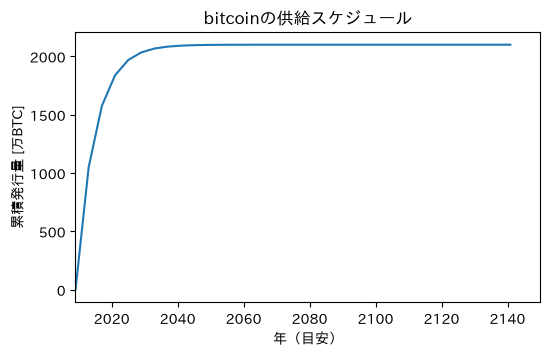

In [5]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401

HALVING_INTERVAL = 210_000
reward = 50 * 10**8  # satoshi
supply, era = 0, 0
heights, supplies = [0], [0]
while reward > 0:
    supply += reward * HALVING_INTERVAL
    era += 1
    heights.append(era * HALVING_INTERVAL)
    supplies.append(supply / 10**8 / 10**4)
    reward //= 2  # 半減（satoshi未満は切り捨て）

print(f"半減回数: {era}, 総発行量: {supply / 10**8:,.8f} BTC")

years = [2009 + h * 10 / 60 / 24 / 365 for h in heights]  # 1ブロック10分として換算
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(years, supplies)  # 各期間内は一定ペースで発行されるので線形補間
ax.set(xlabel="年（目安）", ylabel="累積発行量 [万BTC]", title="bitcoinの供給スケジュール", xlim=(2009, 2150))
plt.show()

発行上限を固定し、発行ペースを徐々に落とすことで、早期参加者へのインセンティブと希少性を両立させている。

## プロトコルのアップグレード

Bitcoinのルール変更は、互換性の観点から2種類に分けられる。

| 種類 | 内容 | 例 |
| --- | --- | --- |
| ソフトフォーク | ルールを厳しくする変更。旧ノードからも新ルールのブロックは有効に見えるため、後方互換性がある | SegWit, Taproot |
| ハードフォーク | ルールを緩める・変える変更。旧ノードは新ルールのブロックを無効と判断するため、チェーンが分裂しうる | Bitcoin Cash の分岐（2017年） |

主なアップグレード：

- **SegWit（Segregated Witness, 2017年）**：署名データ（witness）をトランザクション本体から分離。署名の改変でtxidが変わる問題（トランザクション展性, malleability）を解決し、実質的なブロック容量も増えた（ブロックの上限を1MBから「4M weight units」に変更）。Lightning Networkの前提にもなった
- **Taproot（2021年）**：Schnorr署名とMAST（Merkelized Alternative Script Trees）を導入。複数の署名を1つに集約でき、複雑な条件付き送金も通常の送金と見分けにくくなった

Taprootで拡張されたwitness領域を利用して、satoshiに通し番号を付けて画像などのデータを紐づける **Ordinals**（Bitcoin上のNFT）や、それを使ったトークン規格 **BRC-20** といった使い方も登場している。

Bitcoinの決済速度の限界を補うLightning Networkについては [Layer 2](../scaling/layer2.ipynb) を参照。